importing libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix  




<h1>Dataset Loading</h1>

In [2]:
df = pd.read_csv('dataset/BVBRC_genome_amr.csv', low_memory=False)


In [3]:
print(df.shape)

(171000, 21)


In [4]:
df.head()


,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
0,562,562.174730,Escherichia coli strain UMDUCS23,trimethoprim/sulfamethoxazole,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.94, CI[0.94, 0.95]",Computational Method,NaN,NaN
1,562,562.144628,Escherichia coli 10,ceftriaxone,NaN,<=0.25,<=,0.25,mg/L,MIC,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
2,562,562.529500,Escherichia coli upec-113,ertapenem,NaN,0.5,NaN,0.5,mg/L,NaN,...,NaN,NaN,NaN,NaN,MIC XGBoost Model,202503101.0,"W1 score: 0.77, CI[0.66, 0.89]",Computational Method,NaN,NaN
3,562,562.178148,Escherichia coli PNUSAE022600,aztreonam,NaN,4.0,NaN,4.0,mg/L,NaN,...,NaN,BVBRC,NaN,NaN,MIC XGBoost Model,20250225.0,"W1 score: 0.61, CI[0.5, 0.73]",Computational Method,NaN,NaN
4,562,562.226510,Escherichia coli O23:H16 strain ECO0238,tetracycline,Resistant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.93, CI[0.89, 0.97]",Computational Method,NaN,NaN


In [5]:
df.columns

Index(['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic',
       'Resistant Phenotype', 'Measurement', 'Measurement Sign',
       'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method',
       'Laboratory Typing Method Version', 'Laboratory Typing Platform',
       'Vendor', 'Testing Standard', 'Testing Standard Year',
       'Computational Method', 'Computational Method Version',
       'Computational Method Performance', 'Evidence', 'Source', 'PubMed'],
      dtype='object')

In [6]:
df.dtypes

Taxon ID                              int64
Genome ID                           float64
Genome Name                          object
Antibiotic                           object
Resistant Phenotype                  object
Measurement                          object
Measurement Sign                     object
Measurement Value                    object
Measurement Unit                     object
Laboratory Typing Method             object
Laboratory Typing Method Version     object
Laboratory Typing Platform           object
Vendor                               object
Testing Standard                     object
Testing Standard Year               float64
Computational Method                 object
Computational Method Version        float64
Computational Method Performance     object
Evidence                             object
Source                               object
PubMed                               object
dtype: object

In [7]:
df.describe()

,Taxon ID,Genome ID,Testing Standard Year,Computational Method Version
count,1.710000e+05,1.710000e+05,3701.000000,1.628280e+05
mean,4.943936e+04,4.865374e+04,2019.705755,1.656771e+08
std,2.514143e+05,2.493729e+05,2.044014,7.318143e+07
min,5.620000e+02,5.621000e+02,2008.000000,2.025022e+07
25%,5.620000e+02,5.621468e+02,2018.000000,2.025031e+08
50%,5.620000e+02,5.622211e+02,2021.000000,2.025031e+08
75%,5.620000e+02,5.627044e+02,2021.000000,2.025031e+08
max,3.050630e+06,3.050631e+06,2021.000000,2.025031e+08


<h1>data cleaning and feature engineering</h1>

<h2>handling target variable na values and unrelated outputs</h2>

In [8]:
df['Resistant Phenotype'].isna().sum()

np.int64(87829)

In [9]:
df['Resistant Phenotype'].unique()

array(['Susceptible', nan, 'Resistant', 'Intermediate', 'Nonsusceptible'],
      dtype=object)

In [10]:
df['Resistant Phenotype'].value_counts()

Resistant Phenotype
Susceptible       57912
Resistant         25183
Intermediate         75
Nonsusceptible        1
Name: count, dtype: int64

In [11]:
df = df.dropna(subset=['Resistant Phenotype'])
df.shape

(83171, 21)

In [12]:
df = df[df['Resistant Phenotype'].isin(['Resistant','Susceptible'])]
df.shape

(83095, 21)

In [13]:
print(df['Resistant Phenotype'].value_counts())

Resistant Phenotype
Susceptible    57912
Resistant      25183
Name: count, dtype: int64




<h2>handling duplicates</h2>

In [14]:
df.duplicated().sum()

np.int64(1)

In [15]:
df = df.drop_duplicates()
df.shape

(83094, 21)


<h2>null treatment</h2>

In [16]:
df.isna().sum()

Taxon ID                                0
Genome ID                               0
Genome Name                             0
Antibiotic                              0
Resistant Phenotype                     0
Measurement                         82390
Measurement Sign                    82527
Measurement Value                   82389
Measurement Unit                    82389
Laboratory Typing Method            80090
Laboratory Typing Method Version    83085
Laboratory Typing Platform          82024
Vendor                              65711
Testing Standard                    81096
Testing Standard Year               82527
Computational Method                 3099
Computational Method Version         3099
Computational Method Performance     3099
Evidence                               86
Source                              83094
PubMed                              81293
dtype: int64

In [17]:
df.shape

(83094, 21)

deleting columns having less null values greater than the threshold

In [18]:
threshold = 0.7 * len(df)

print("maximum null values a column can contains: " , threshold)


maximum null values a column can contains:  58165.799999999996


In [19]:
df = df.dropna(axis=1, thresh=threshold)

df.isna().sum()

Taxon ID                               0
Genome ID                              0
Genome Name                            0
Antibiotic                             0
Resistant Phenotype                    0
Computational Method                3099
Computational Method Version        3099
Computational Method Performance    3099
Evidence                              86
dtype: int64

dropping the computational method as it contain one one value that didn't give any information for the output

In [20]:
df['Computational Method'].value_counts()

Computational Method
SIR XGBoost Model    79995
Name: count, dtype: int64

In [21]:
df = df.drop(columns=['Computational Method'])

In [22]:
df.isna().sum()

Taxon ID                               0
Genome ID                              0
Genome Name                            0
Antibiotic                             0
Resistant Phenotype                    0
Computational Method Version        3099
Computational Method Performance    3099
Evidence                              86
dtype: int64

removing taxon id because it is predictable from the genome id adn cramer's V show 99.5 percent correlation and theoritcally genome id belong to a single taxon id

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape)-1)))

v = cramers_v(df['Taxon ID'], df['Genome ID'])
print(f"Cramer's V: {v}")

Cramer's V: 0.9969007913454884


In [24]:
df = df.drop(columns=['Taxon ID'])
df.isna().sum()

Genome ID                              0
Genome Name                            0
Antibiotic                             0
Resistant Phenotype                    0
Computational Method Version        3099
Computational Method Performance    3099
Evidence                              86
dtype: int64

Handling genome name and genome id issue of count and droping genome id and also making the genome name consistent

In [25]:
print("genome id count: ", df['Genome ID'].value_counts().sum())
print("genome name count: ",df['Genome Name'].value_counts().sum())

genome id count:  83094
genome name count:  83094


In [26]:
df = df.drop(columns=['Genome ID'])
df.isna().sum()

Genome Name                            0
Antibiotic                             0
Resistant Phenotype                    0
Computational Method Version        3099
Computational Method Performance    3099
Evidence                              86
dtype: int64

In [27]:
df['Genome Name'] = df['Genome Name'].str.strip().str.strip("'")

..

In [28]:
df.isna().sum()

Genome Name                            0
Antibiotic                             0
Resistant Phenotype                    0
Computational Method Version        3099
Computational Method Performance    3099
Evidence                              86
dtype: int64

Dropping 'Computational Method Version' and 'Computational Method Performance' and 'evidence' and there was also no need of the above column dropeed using the threadhold otherwise we will drop them  
REASONING: 
1. These are metadata about the PREVIOUS model used to generate labels, 
    not biological traits of the bacteria. 
2. Including them would cause "Data Leakage," where the model learns 
    software versions instead of antimicrobial resistance patterns.
3. High cardinality in 'Version' causes unnecessary memory overhead.

In [29]:
df = df.drop(columns=['Computational Method Version', 'Computational Method Performance', 'Evidence'])

In [30]:
df.isna().sum()

Genome Name            0
Antibiotic             0
Resistant Phenotype    0
dtype: int64

C:\Users\M.Zaid Naeem\AppData\Local\Temp\ipykernel_13248\273952427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Resistant Phenotype', data=df, palette='Set2')


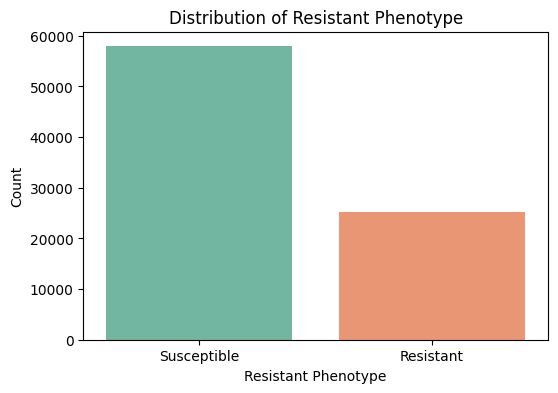

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Resistant Phenotype', data=df, palette='Set2')
plt.title('Distribution of Resistant Phenotype')
plt.xlabel('Resistant Phenotype')
plt.ylabel('Count')
plt.show()

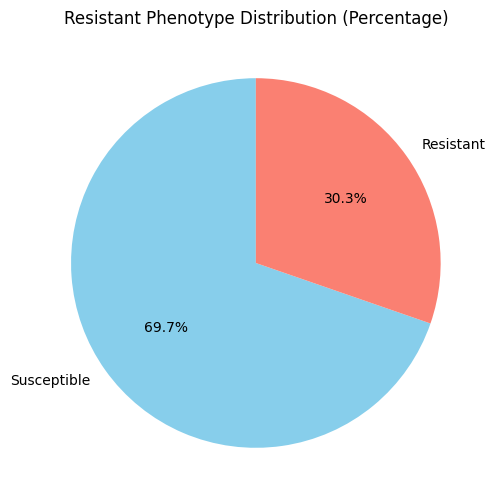

In [32]:
counts = df['Resistant Phenotype'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['skyblue','salmon'], startangle=90)
plt.title('Resistant Phenotype Distribution (Percentage)')
plt.show()

we cannot do the box plot, shekwnees and outliers checks as all the columns are categorical that left

<h1>Handling class imbalance and training after doing hyperparameter tunning using optuan</h1>

In [33]:
X = df.drop('Resistant Phenotype', axis=1)
y = df['Resistant Phenotype']

In [34]:
ordinal_encoder = OrdinalEncoder()
X['Genome Name'] = ordinal_encoder.fit_transform(X[['Genome Name']])


In [35]:
X = pd.get_dummies(X, columns=['Antibiotic'])

In [36]:
le = LabelEncoder()
y = le.fit_transform(y)
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)


{'Resistant': np.int64(0), 'Susceptible': np.int64(1)}


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [38]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [39]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': (sum(y_train == 0) / sum(y_train == 1)),
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    model = XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    
    return np.mean(auc_scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Hyperparameters:", study.best_params)


best_params = study.best_params
best_params['scale_pos_weight'] = (sum(y_train == 0) / sum(y_train == 1))
best_params['eval_metric'] = 'logloss'


final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)


[I 2026-03-28 17:14:14,852] A new study created in memory with name: no-name-6d5b90d7-d1fe-4d91-b127-bd81b78a34b6
[I 2026-03-28 17:14:23,839] Trial 0 finished with value: 0.8652033759669537 and parameters: {'n_estimators': 118, 'max_depth': 5, 'learning_rate': 0.15067912734817834, 'subsample': 0.9144347448247357, 'colsample_bytree': 0.792372732409516, 'gamma': 0.4713106362352165, 'reg_alpha': 2.979436192145535, 'reg_lambda': 3.153122066795099}. Best is trial 0 with value: 0.8652033759669537.
[I 2026-03-28 17:14:52,007] Trial 1 finished with value: 0.8897536196450073 and parameters: {'n_estimators': 430, 'max_depth': 8, 'learning_rate': 0.09271444199630663, 'subsample': 0.9043409310311088, 'colsample_bytree': 0.8572238320357812, 'gamma': 3.760508724846527, 'reg_alpha': 3.430490683153285, 'reg_lambda': 2.430718429209084}. Best is trial 1 with value: 0.8897536196450073.
[I 2026-03-28 17:15:09,394] Trial 2 finished with value: 0.8482158572767622 and parameters: {'n_estimators': 242, 'max_d

Best Hyperparameters: {'n_estimators': 408, 'max_depth': 10, 'learning_rate': 0.2315943299883087, 'subsample': 0.605158802939256, 'colsample_bytree': 0.9553220284774916, 'gamma': 0.6293362442928374, 'reg_alpha': 2.46803909857619, 'reg_lambda': 1.7349905444022906}


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9553220284774916
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



Best Hyperparameters: {'n_estimators': 408, 'max_depth': 10, 'learning_rate': 0.2315943299883087, 'subsample': 0.605158802939256, 'colsample_bytree': 0.9553220284774916, 'gamma': 0.6293362442928374, 'reg_alpha': 2.46803909857619, 'reg_lambda': 1.7349905444022906}


In [40]:
from xgboost import XGBClassifier

best_params = {
    'n_estimators': 408,
    'max_depth': 10,
    'learning_rate': 0.2315943299883087,
    'subsample': 0.605158802939256,
    'colsample_bytree': 0.9553220284774916,
    'gamma': 0.6293362442928374,
    'reg_alpha': 2.46803909857619,
    'reg_lambda': 1.7349905444022906,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)



c:\Users\M.Zaid Naeem\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:05:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9553220284774916
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [64]:
y_pred = final_model.predict(X_test)

In [66]:


from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))


0.7477585895661593


In [67]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.51      0.55      5037
           1       0.80      0.85      0.82     11582

    accuracy                           0.75     16619
   macro avg       0.70      0.68      0.69     16619
weighted avg       0.74      0.75      0.74     16619



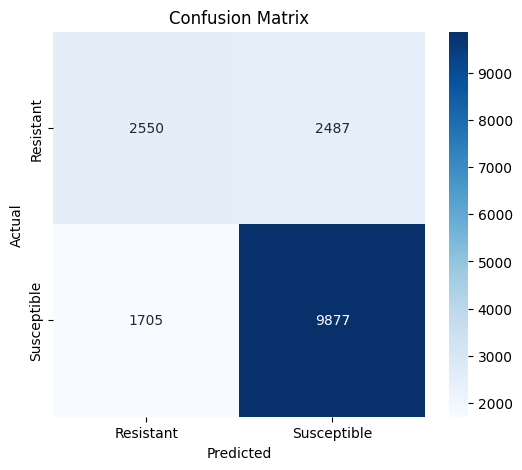

In [42]:
# Predictions
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Test AUC: 0.7893476462744161


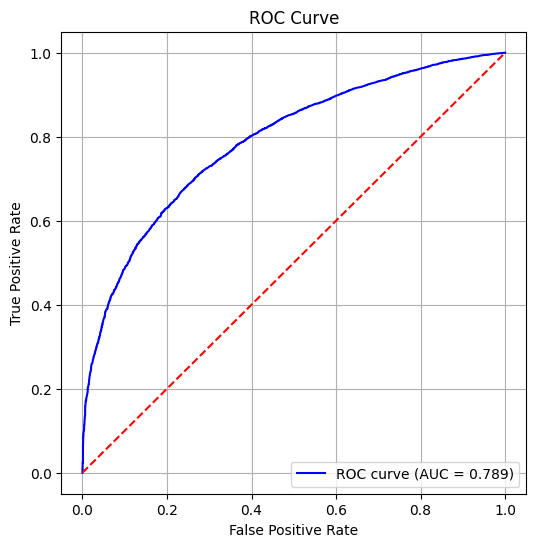

In [ ]:


y_test_encoded = le.fit_transform(y_test)

# Predict probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)
auc_score = roc_auc_score(y_test_encoded, y_prob)
print("Test AUC:", auc_score)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<h1>Bonus</h1>

<h1>Predictive Dataset</h1>

In [61]:
import pandas as pd


decoded_genome = ordinal_encoder.inverse_transform(X_test[['Genome Name']]).flatten()

# -------------------------------
# 2. Decode Antibiotic (from one-hot)
# -------------------------------
antibiotic_cols = [col for col in X_test.columns if col.startswith('Antibiotic_')]

decoded_antibiotic = X_test[antibiotic_cols].idxmax(axis=1)
decoded_antibiotic = decoded_antibiotic.str.replace('Antibiotic_', '')

# -------------------------------
# 3. Decode Predictions
# -------------------------------
y_pred_labels = le.inverse_transform(y_pred)

# -------------------------------
# 4. Create Final DataFrame
# -------------------------------
final_df = pd.DataFrame({
    'Genome Name': decoded_genome,
    'Antibiotic': decoded_antibiotic,
    'Predicted Resistant Phenotype': y_pred_labels
})

# -------------------------------
# 5. Save to CSV
# -------------------------------
final_df.to_csv('submission/predictions.csv')

print("CSV file created successfully ✅")


CSV file created successfully ✅


In [60]:
final_df

,Genome Name,Antibiotic,Predicted Resistant Phenotype
107291,Escherichia coli VREC1291,norfloxacin,Susceptible
41015,Escherichia coli q1-7,ceftriaxone,Susceptible
105020,Escherichia coli strain 710451,sulfamethoxazole,Resistant
147089,Escherichia coli strain 52,cefalothin,Resistant
11539,Escherichia coli Map_103_027,meropenem,Susceptible
...,...,...,...
15177,Escherichia coli 1429,piperacillin/tazobactam,Susceptible
27735,Escherichia coli MSG35-C01,tobramycin,Susceptible
50155,Escherichia coli 18-4,streptomycin,Resistant
163094,Escherichia coli PNUSAE018069,nalidixic acid,Susceptible


In [ ]:
import joblib

joblib.dump(final_model, 'submission/xgb_model.pkl')
joblib.dump(ordinal_encoder, 'submission/ordinal_encoder.pkl')
joblib.dump(le, 'submission/label_encoder.pkl')


Text(0.5, 1.0, 'Top 10 Feature Import')

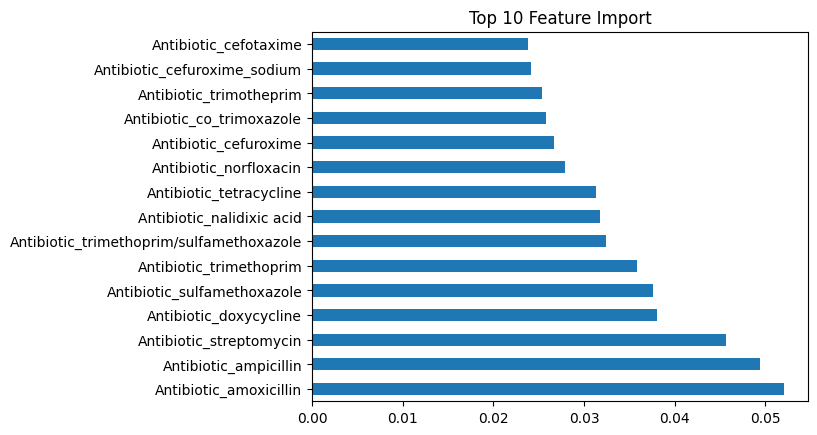

In [62]:
importances = final_model.feature_importances_
feature_names = X.columns

# 2. Organize them into a Pandas Series for easy plotting
feat_importances = pd.Series(importances, index=feature_names)

# 3. Sort and plot the top 10
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Top 10 Feature Import")